# Decision Tree Classifier

This notebook guides you through implementing a Decision Tree Classifier using the Breast Cancer dataset. We'll cover data preparation, model training, hyperparameter tuning, evaluation, and feature importance.

## Table of Contents

1. [Imports](#scrollTo=BL17qaclM8FP)
2. [Dataset Preparation](#scrollTo=BqTJhYQQM8Cr)
3. [Decision Tree Model - Training & Evaluation](#scrollTo=L0yEgVOcM7ic)
4. [Hyperparameter Tuning](#scrollTo=auBGv2e2M7gA)
5. [Feature Importance](#scrollTo=PKEn_h2uM7al)
6. [Model Evaluation](#scrollTo=0cRNdifLM7db)
7. [Conclusion](#scrollTo=y_sKvEAtM7XF)
8. [References](#scrollTo=OKSPRIoGP1nQ)

# Imports

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)

# For permutation importance
from sklearn.inspection import permutation_importance

# Dataset Preparation

### 2.1. Loading Dataset

In [2]:
# Load the Breast Cancer dataset
data = load_breast_cancer()

# Create a DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# Display the first five rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### 2.2. Dataset Overview

In [3]:
# Basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nFeature Names:", data.feature_names)
print("\nTarget Classes:", data.target_names)

Dataset Shape: (569, 31)

Feature Names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Classes: ['malignant' 'benign']


### 2.3. Check Class Distribution

In [4]:
class_distribution = df['target'].value_counts(normalize=True)
print(class_distribution)

target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


*The dataset is relatively balanced (67% malignant, 33% benign), making it suitable for binary classification without significant imbalance concerns.*


### 2.4. Data Preprocessing

**Proper preprocessing ensures that features contribute appropriately to the model. However, Decision Trees are not sensitive to feature scaling or feature correlation, so these steps are optional.**


In [5]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (455, 30)
Testing set size: (114, 30)


**Note:** Decision Trees are not sensitive to feature scaling or highly correlated features. They can handle both without the need for scaling or feature reduction.

Therefore, we will proceed without scaling or removing correlated features.

This simplifies the preprocessing steps and reduces computational overhead.


# Decision Tree Model - Training & Evaluation

### 3.1. Basic Decision Tree with Default Parameters

Accuracy: 0.91


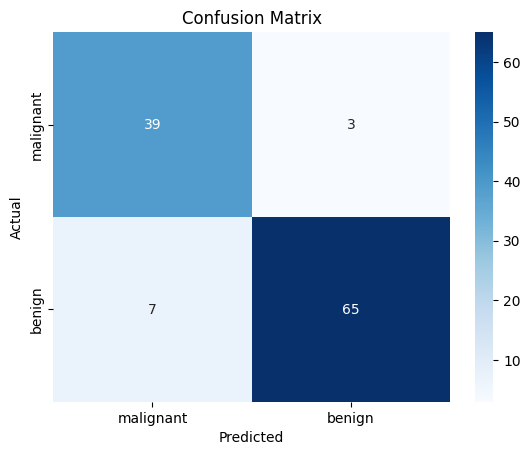

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



In [6]:
# Initialize Decision Tree Classifier with default parameters
dtree = DecisionTreeClassifier(random_state=42)

# Fit the model
dtree.fit(X_train, y_train)

# Predict on test data
y_pred = dtree.predict(X_test)

# Evaluate Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Hyperparameter Tuning

### GridSearch for Optimal Decision Tree Parameters

In [7]:
# Define the parameter grid
param_grid = {
    'max_depth': [None, 3, 5, 7, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search
grid.fit(X_train, y_train)

# Best parameters
print(f"Best parameters: {grid.best_params_}")

# Best cross-validation accuracy
print(f"Best cross-validation accuracy: {grid.best_score_:.2f}")

Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best cross-validation accuracy: 0.94


### Retrain with Optimal Parameters


In [8]:
# Get the best parameters
best_params = grid.best_params_

# Initialize Decision Tree with best parameters
dtree_best = DecisionTreeClassifier(**best_params, random_state=42)

# Fit the model
dtree_best.fit(X_train, y_train)

# Predict on test data
y_pred_best = dtree_best.predict(X_test)

# Evaluate
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy with Optimal Parameters: {accuracy_best:.2f}")

Test Accuracy with Optimal Parameters: 0.92


### Cross-Validation Scores

In [9]:
# Cross-validation scores using StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_skf = cross_val_score(dtree_best, X_train, y_train, cv=skf, scoring='accuracy')

# Cross-validation scores using KFold
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores_kf = cross_val_score(dtree_best, X_train, y_train, cv=kf, scoring='accuracy')

print(f"Mean CV Accuracy (StratifiedKFold): {cv_scores_skf.mean():.2f}")
print(f"Mean CV Accuracy (KFold): {cv_scores_kf.mean():.2f}")

Mean CV Accuracy (StratifiedKFold): 0.94
Mean CV Accuracy (KFold): 0.93


# Feature Importance

Understanding which features contribute most to the model's predictions is essential for interpretation and gaining insights into the data.

### 6.1. Feature Importance from Decision Tree

<ipython-input-10-e2c4c6e94645>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances_sorted.values, y=feature_importances_sorted.index, palette='viridis')


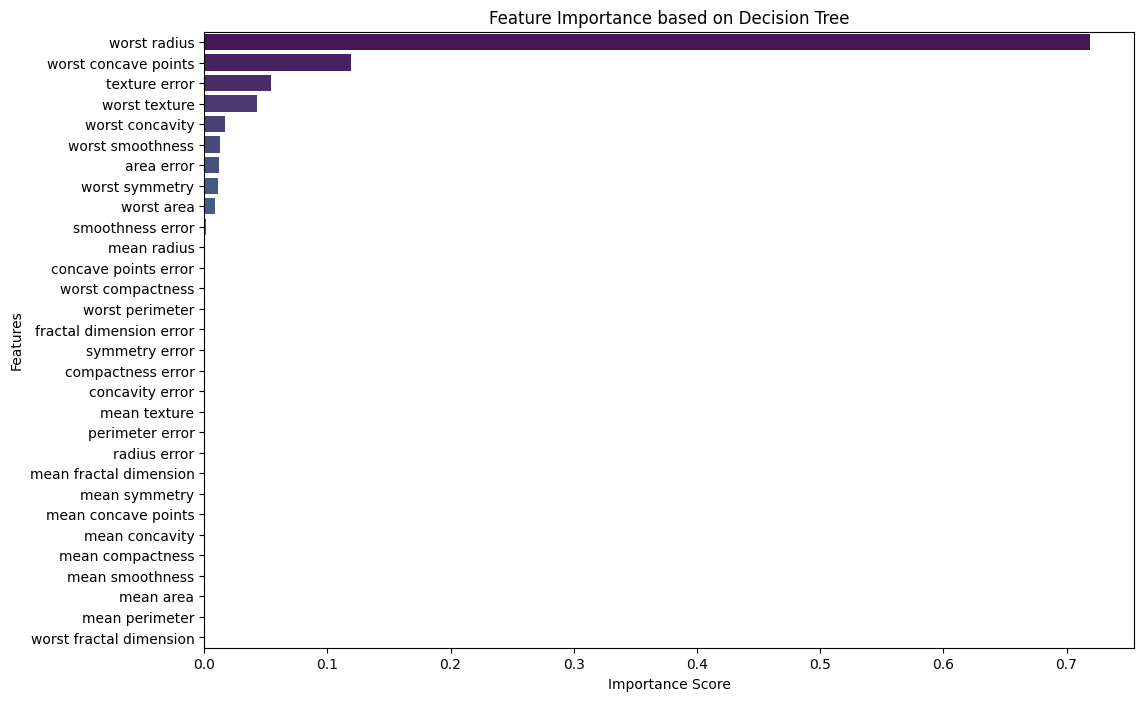

In [10]:
# Extract feature importances from the best Decision Tree model
feature_importances = pd.Series(dtree_best.feature_importances_, index=X_train.columns)

# Sort features by importance
feature_importances_sorted = feature_importances.sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances_sorted.values, y=feature_importances_sorted.index, palette='viridis')
plt.title('Feature Importance based on Decision Tree')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### 6.2. Top Important Features

Top 10 Important Features:
worst radius            0.718940
worst concave points    0.119597
texture error           0.054255
worst texture           0.043286
worst concavity         0.016819
worst smoothness        0.013062
area error              0.012451
worst symmetry          0.011058
worst area              0.008708
smoothness error        0.001824
dtype: float64


<ipython-input-11-6bc1cce05627>:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='tab10')


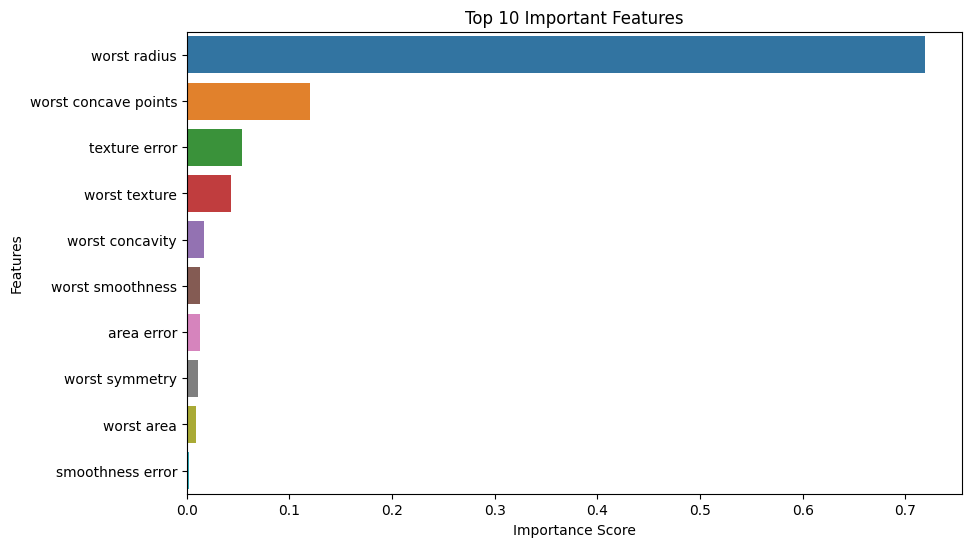

In [11]:
# Display top 10 important features
top_features = feature_importances_sorted.head(10)
print("Top 10 Important Features:")
print(top_features)

# Plotting top features
plt.figure(figsize=(10, 6))
sns.barplot(x=top_features.values, y=top_features.index, palette='tab10')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

### 6.3. Visualizing the Decision Tree

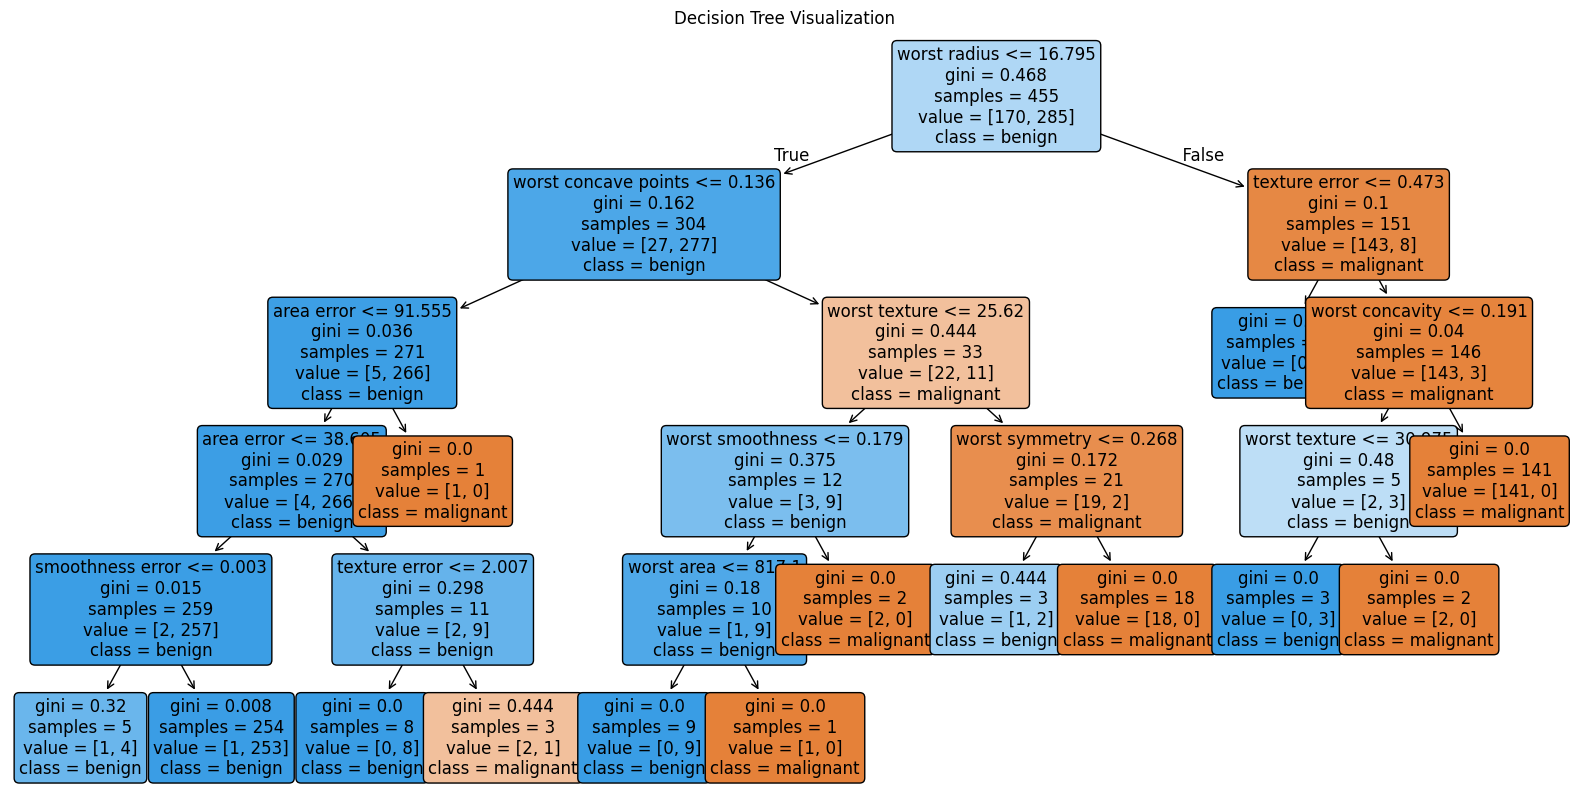

In [12]:
plt.figure(figsize=(20,10))
plot_tree(
    dtree_best,
    feature_names=X_train.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Decision Tree Visualization')
plt.show()

### 6.4. Permutation Importance

Permutation Importance measures the increase in the model's prediction error when a single feature's values are randomly shuffled.

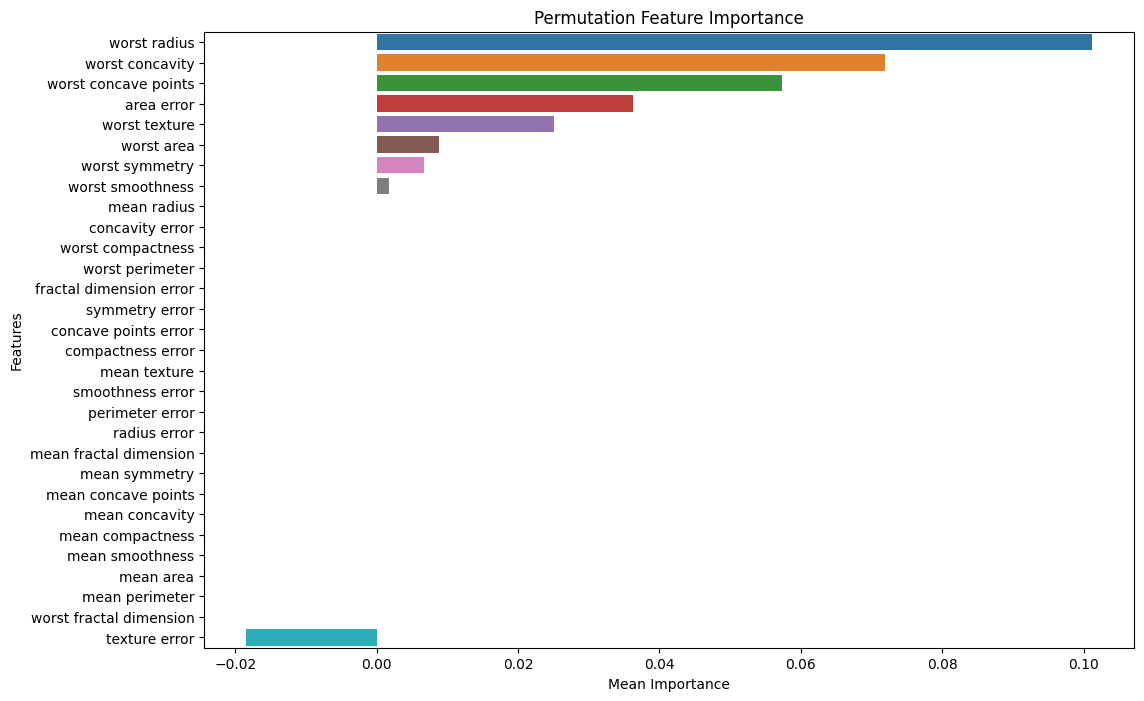

In [13]:
# Compute permutation importance on the best model
perm_importance = permutation_importance(
    dtree_best, X_test, y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

# Create a DataFrame for feature importance
perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values(by='Importance Mean', ascending=False)

# Plot permutation importance
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance Mean',
    y='Feature',
    hue='Feature',
    legend=False,
    data=perm_importance_df,
    palette='tab10'
)
plt.title('Permutation Feature Importance')
plt.xlabel('Mean Importance')
plt.ylabel('Features')
plt.show()

# Advanced Decision Tree Techniques

In this section, we'll explore advanced techniques for enhancing Decision Tree models, focusing on **Pruning** to prevent overfitting and improve model generalization.

### 7.1. Cost-Complexity Pruning (Post-Pruning)

**Pruning** helps in reducing the complexity of the Decision Tree, thereby preventing overfitting.

Scikit-learn provides a parameter called `ccp_alpha` (Cost-Complexity Pruning Alpha) to perform pruning.

We'll explore how to determine the optimal `ccp_alpha` using cross-validation.


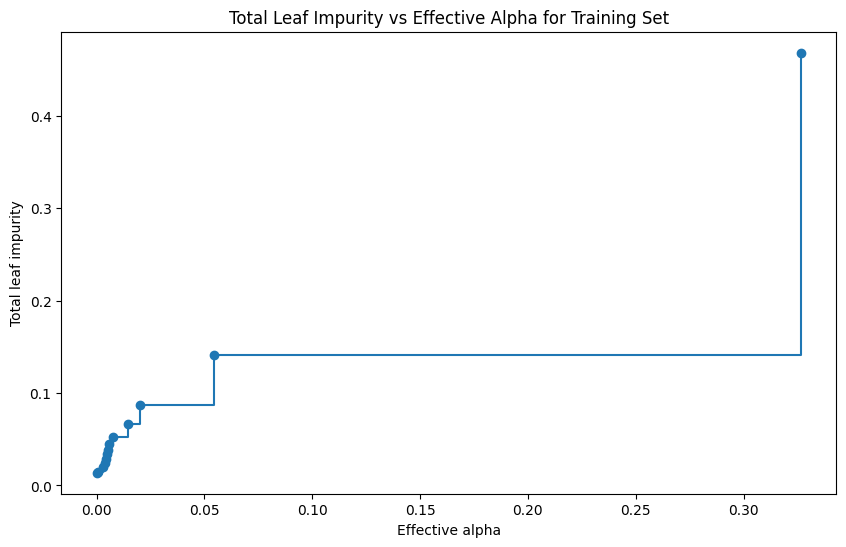

In [14]:
# Import necessary library for cost-complexity pruning
from sklearn.tree import DecisionTreeClassifier

# Retrieve effective alphas and corresponding total leaf impurities
path = dtree_best.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

# Plot total leaf impurities vs effective alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, impurities, marker='o', drawstyle="steps-post")
plt.xlabel("Effective alpha")
plt.ylabel("Total leaf impurity")
plt.title("Total Leaf Impurity vs Effective Alpha for Training Set")
plt.show()


#### Selecting the Optimal `ccp_alpha`

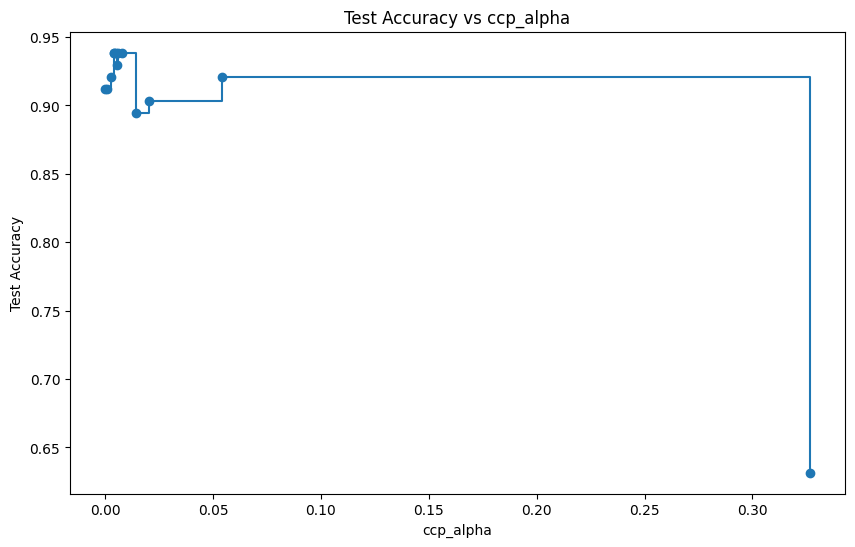

Optimal ccp_alpha: 0.0040
Test Accuracy at Optimal ccp_alpha: 0.94


In [15]:
# Initialize lists to store results
clfs = []
scores = []

# Iterate over all alphas to train and evaluate trees
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)
    scores.append(clf.score(X_test, y_test))

# Plot test accuracy vs alpha
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, scores, marker='o', drawstyle="steps-post")
plt.xlabel("ccp_alpha")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy vs ccp_alpha")
plt.show()

# Find the alpha that gives the highest accuracy
optimal_idx = np.argmax(scores)
optimal_ccp_alpha = ccp_alphas[optimal_idx]
print(f"Optimal ccp_alpha: {optimal_ccp_alpha:.4f}")
print(f"Test Accuracy at Optimal ccp_alpha: {scores[optimal_idx]:.2f}")

#### Pruning the Tree with Optimal `ccp_alpha`

Test Accuracy after Pruning: 0.94


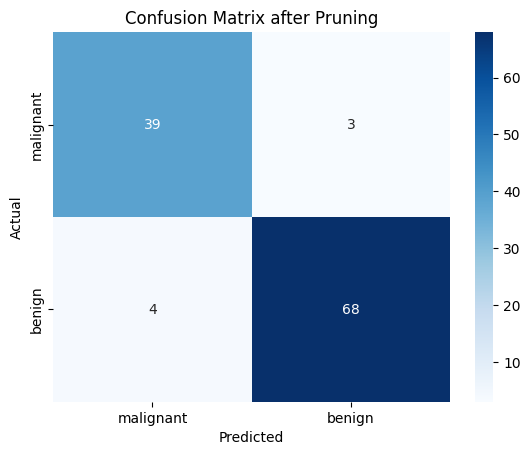

              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



In [16]:
# Prune the tree using the optimal ccp_alpha
dtree_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=optimal_ccp_alpha)
dtree_pruned.fit(X_train, y_train)

# Predict on test data
y_pred_pruned = dtree_pruned.predict(X_test)

# Evaluate pruned tree
accuracy_pruned = accuracy_score(y_test, y_pred_pruned)
print(f"Test Accuracy after Pruning: {accuracy_pruned:.2f}")

# Confusion Matrix for Pruned Tree
cm_pruned = confusion_matrix(y_test, y_pred_pruned)
sns.heatmap(
    cm_pruned, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix after Pruning')
plt.show()

# Classification Report for Pruned Tree
print(classification_report(y_test, y_pred_pruned, target_names=data.target_names))

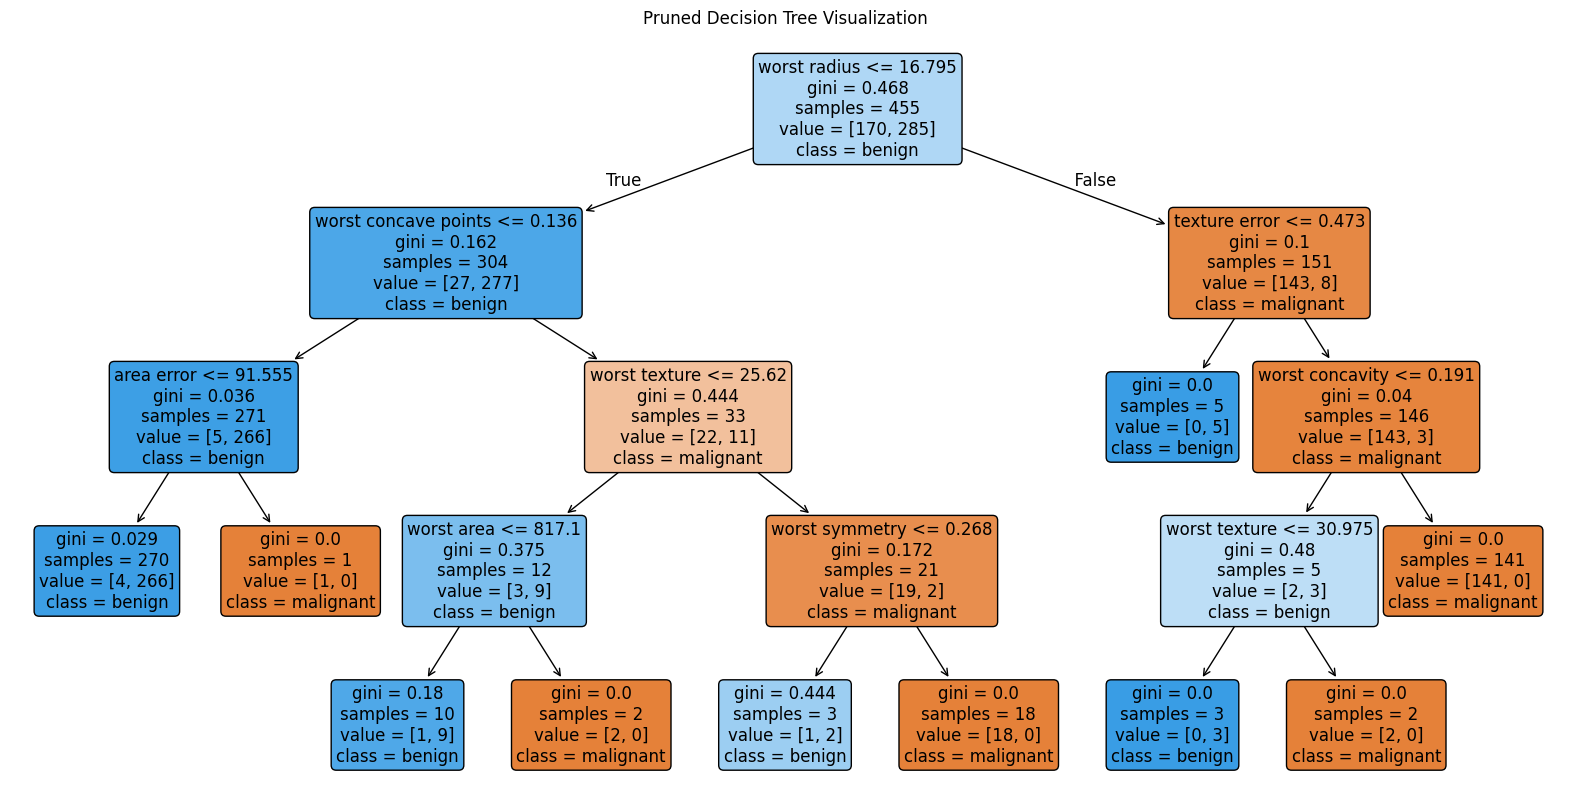

In [17]:
plt.figure(figsize=(20,10))
plot_tree(
    dtree_pruned,
    feature_names=X_train.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Pruned Decision Tree Visualization')
plt.show()

### 7.2. Limiting Tree Depth (Pre-Pruning)

Another technique to control the complexity of the Decision Tree is by limiting its depth during training.

This is known as **Pre-Pruning**.


Test Accuracy with Limited Depth: 0.94


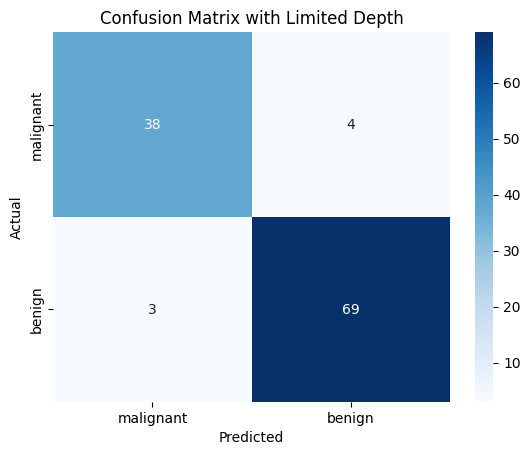

              precision    recall  f1-score   support

   malignant       0.93      0.90      0.92        42
      benign       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



In [18]:
# Initialize Decision Tree with limited depth
dtree_limited = DecisionTreeClassifier(
    max_depth=3,  # Limiting the depth
    random_state=42
)

# Fit the model
dtree_limited.fit(X_train, y_train)

# Predict on test data
y_pred_limited = dtree_limited.predict(X_test)

# Evaluate
accuracy_limited = accuracy_score(y_test, y_pred_limited)
print(f"Test Accuracy with Limited Depth: {accuracy_limited:.2f}")

# Confusion Matrix
cm_limited = confusion_matrix(y_test, y_pred_limited)
sns.heatmap(
    cm_limited, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with Limited Depth')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_limited, target_names=data.target_names))

#### Visualizing the Limited Depth Tree

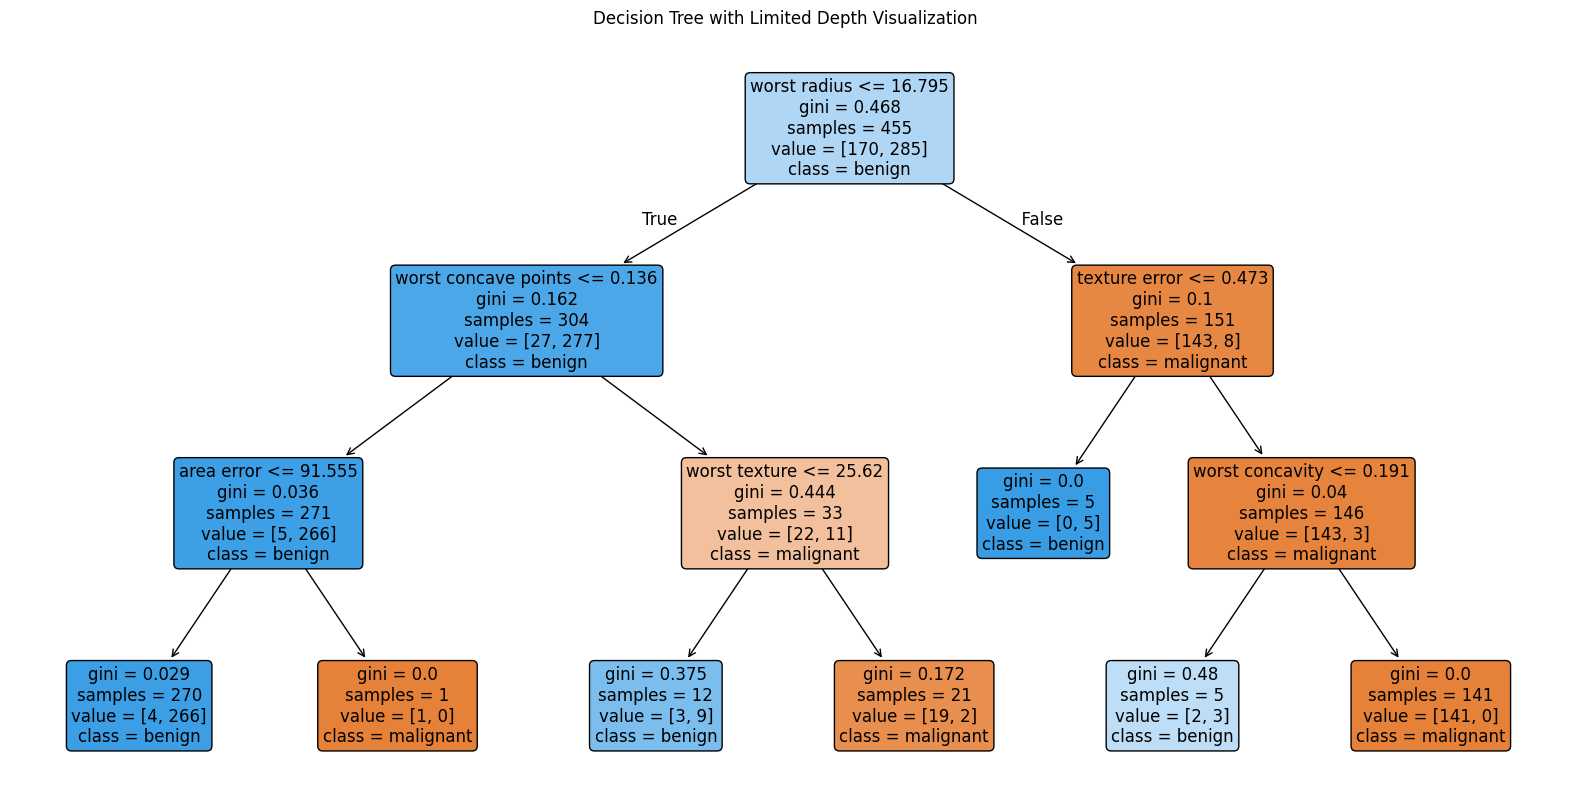

In [19]:
plt.figure(figsize=(20,10))
plot_tree(
    dtree_limited,
    feature_names=X_train.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Decision Tree with Limited Depth Visualization')
plt.show()

### 7.3. Minimum Samples Split and Leaf


Adjusting the `min_samples_split` and `min_samples_leaf` parameters can control the complexity of the tree by setting the minimum number of samples required to split an internal node or to be at a leaf node.

Test Accuracy with min_samples_split=10 and min_samples_leaf=5: 0.93


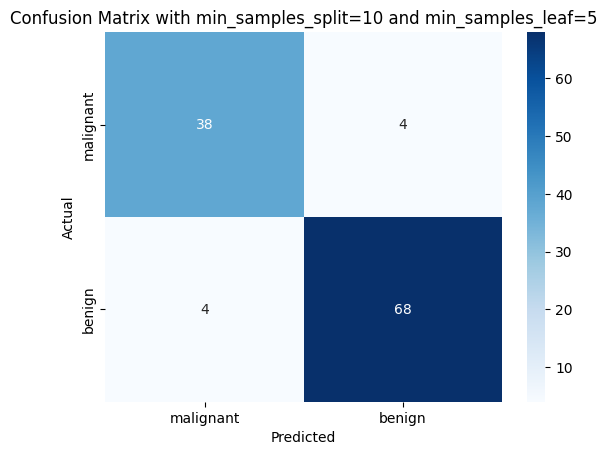

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [20]:
# Initialize Decision Tree with higher min_samples_split and min_samples_leaf
dtree_min_samples = DecisionTreeClassifier(
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Fit the model
dtree_min_samples.fit(X_train, y_train)

# Predict on test data
y_pred_min_samples = dtree_min_samples.predict(X_test)

# Evaluate
accuracy_min_samples = accuracy_score(y_test, y_pred_min_samples)
print(f"Test Accuracy with min_samples_split=10 and min_samples_leaf=5: {accuracy_min_samples:.2f}")

# Confusion Matrix
cm_min_samples = confusion_matrix(y_test, y_pred_min_samples)
sns.heatmap(
    cm_min_samples, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with min_samples_split=10 and min_samples_leaf=5')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred_min_samples, target_names=data.target_names))

#### Visualizing the Tree with Minimum Samples Constraints

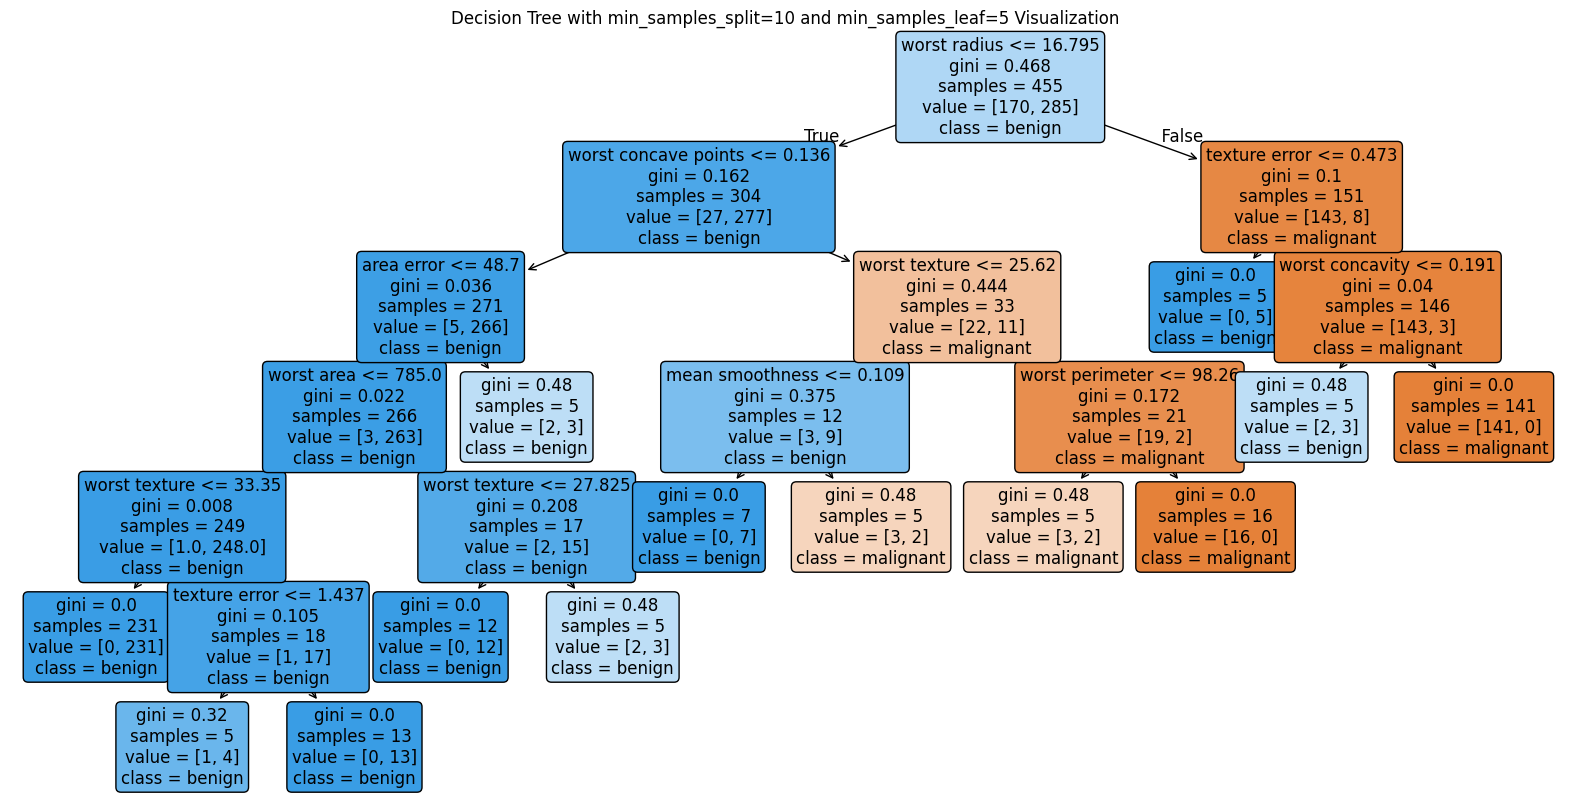

In [21]:
plt.figure(figsize=(20,10))
plot_tree(
    dtree_min_samples,
    feature_names=X_train.columns,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('Decision Tree with min_samples_split=10 and min_samples_leaf=5 Visualization')
plt.show()

# Model Evaluation

### Accuracy Score

In [ ]:
accuracy = accuracy_score(y_test, y_pred_best)
print(f"Accuracy: {accuracy:.2f}")

### Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names).plot(
    cmap='Blues', values_format='d'
)
plt.title('Confusion Matrix')
plt.show()

### Classification Report

In [ ]:
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

### Estimate Probabilities

Decision Trees can produce class probabilities **by calculating the proportion of samples of each class in the leaf nodes**.

These probabilities can be used for various evaluation metrics like ROC and Precision-Recall curves.


In [ ]:
# Predict probabilities for ROC
y_proba = dtree_best.predict_proba(X_test)[:,1]

### Receiver Operator Characteristic Curve (ROC Curve)

In [ ]:
# Compute ROC curve and AUC
def plot_roc_curve_custom(y_true, y_prob, model_name='Decision Tree'):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0,1], [0,1], 'k--')  # Diagonal
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.show()

plot_roc_curve_custom(y_test, y_proba)

### Precision-Recall Curve and Average Precision

In [ ]:
def plot_precision_recall_curve_custom(y_true, y_prob, model_name='Decision Tree', pos_label=1):
    """
    Plots the Precision-Recall curve for a binary classifier.
    """
    # Calculate precision-recall pairs for different probability thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob, pos_label=pos_label)
    avg_precision = average_precision_score(y_true, y_prob)

    # Plot Precision-Recall curve
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, color='b', linewidth=2, label=f'AP = {avg_precision:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {model_name}')
    plt.legend(loc='lower left')
    plt.grid(True)
    plt.show()

    return avg_precision

avg_precision = plot_precision_recall_curve_custom(y_test, y_proba)

### Class Score Distribution

In [ ]:
def plot_class_score_distribution(y_true, y_prob):
    """
    Plots the class score distribution for two classes based on two arrays.
    """
    plt.figure(figsize=(8, 6))

    # Plot KDE for each class
    for class_value, color, linestyle in zip(np.unique(y_true), ['darkorange', 'navy'], ['-', '--']):
        subset_scores = y_prob[np.array(y_true) == class_value]
        sns.kdeplot(
            subset_scores,
            color=color,
            linestyle=linestyle,
            label=f'Class {data.target_names[class_value]}',
            fill=True,
            alpha=0.3
        )

    # Add legend, labels, and title
    plt.legend(title="Class")
    plt.xlabel('Estimated Probability')
    plt.ylabel('Density')
    plt.title('Class Score Distribution')
    plt.show()

plot_class_score_distribution(y_test, y_proba)

### Estimating Optimal Threshold

#### Optimal Threshold Based on F1 Score

In [ ]:
def find_optimal_threshold(y_true, y_prob):
    """
    Finds the optimal threshold based on F1 score and provides insights using PR curve.
    """
    # Calculate precision, recall, thresholds for PR Curve
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)

    # Method 1: Using F1 score
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)  # Avoid division by zero
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold_f1 = thresholds[optimal_idx]

    # Method 2: Midpoint of precision and recall (for balanced precision and recall)
    pr_diff = np.abs(precision - recall)
    optimal_idx_pr = np.argmin(pr_diff)
    optimal_threshold_pr_balance = thresholds[optimal_idx_pr]

    # Collect results
    optimal_thresholds = {
        "F1_score": optimal_threshold_f1,
        "Precision-Recall_Balance": optimal_threshold_pr_balance
    }

    # Plot Precision-Recall curve with marked optimal thresholds
    plt.figure(figsize=(10, 6))
    plt.plot(recall, precision, label='PR Curve', color='blue')
    plt.scatter(recall[optimal_idx], precision[optimal_idx], color='red',
                label=f'Optimal F1 Threshold = {optimal_threshold_f1:.2f}')
    plt.scatter(recall[optimal_idx_pr], precision[optimal_idx_pr], color='green',
                label=f'Balanced PR Threshold = {optimal_threshold_pr_balance:.2f}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Optimal Thresholds')
    plt.legend(loc='lower left')
    plt.grid()
    plt.show()

    return optimal_thresholds

optimal_thresholds = find_optimal_threshold(y_test, y_proba)

#### Youden's J Statistic (Optimal ROC Threshold)

In [ ]:
def optimal_threshold_youden(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    youden_j = tpr - fpr
    optimal_idx = np.argmax(youden_j)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Optimal Threshold (Youden's J): {optimal_threshold:.2f}")
    return optimal_threshold

optimal_threshold = optimal_threshold_youden(y_test, y_proba)

# Adjust predictions based on the optimal threshold
y_hat_adj = (y_proba > optimal_threshold).astype(int)

# Classification report with adjusted threshold
print("Classification Report with Optimal Threshold:")
print(classification_report(y_test, y_hat_adj, target_names=data.target_names))

print("Classification Report with Default Threshold (0.5):")
print(classification_report(y_test, y_pred_best, target_names=data.target_names))

#### Maximizing Specificity and Sensitivity Balance

In [ ]:
def optimal_threshold_sensitivity_specificity(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    specificity = 1 - fpr
    balance = np.abs(specificity - tpr)
    optimal_idx = np.argmin(balance)
    optimal_threshold = thresholds[optimal_idx]
    print(f"Optimal Threshold (Sensitivity-Specificity Balance): {optimal_threshold:.2f}")
    return optimal_threshold

optimal_threshold_balance = optimal_threshold_sensitivity_specificity(y_test, y_proba)

# Conclusion

In this notebook, we've successfully implemented a **Decision Tree Classifier** on the Breast Cancer dataset. We've covered data preparation, model training, hyperparameter tuning, evaluation, and feature importance analysis. Decision Trees offer intuitive models that are easy to interpret, making them a valuable tool in the machine learning toolkit.

# References

- [Scikit-learn Documentation](https://scikit-learn.org/stable/documentation.html)
- [Decision Trees Explained](https://en.wikipedia.org/wiki/Decision_tree_learning)
- [Permutation Importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
- [Cost-Complexity Pruning](https://scikit-learn.org/stable/modules/tree.html#cost-complexity-pruning)